# From Focus to Interaction Structure

This notebook summarizes how effect size (Cramér’s V) and statistical evidence (p-values) evolve as progressively richer interaction structures are introduced. Across both the combined and goal split subgroups, the strongest patterns emerge when focus is interpreted jointly with goal type and agency rather than in isolation. In addition, furhter differences are explored between goal behaviour (frequent and non_frequent) and no goal as a result of previous EDA as well as how those differ from the combined dataset separately. 

After looking into consequent reversibility as a theoretical new variable that could be taken on board with the intention to see what else could be adding complexity to the structure's resolution, it has finally been discarded given that it overlaps with goal type.

Import libraries

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Summary Results: Combined vs. Goals

1. Figure 1: χ² Progression
2. Figure 2: Declining p-values
3. Figure 3: Increasing Effect Size

In [156]:
effect_type = ["Focus", "Goal x Focus", "Agency x Focus", "Goal x Agency x Focus"]

chi_sq_combined = [1.866, 13.718, 12.364, 32.111]
chi_sq_goals = [5.437, 11.188, 17.590, 26.419]

p_combined = [0.3934, 0.1863, 0.0543, 0.0755]
p_goals = [0.0660, 0.0827, 0.0073, 0.0229]

V_combined = [0.098, 0.188, 0.178, 0.287]
V_goals = [0.204, 0.207, 0.259, 0.318]

## Figure 1: χ² Progression

In [157]:

chi_sq_df = pd.DataFrame({"effect_type": effect_type, "chi_sq_combined": chi_sq_combined, "chi_sq_goals": chi_sq_goals})
chi_sq_df.set_index("effect_type")

,chi_sq_combined,chi_sq_goals
effect_type,,
Focus,1.866,5.437
Goal x Focus,13.718,11.188
Agency x Focus,12.364,17.590
Goal x Agency x Focus,32.111,26.419


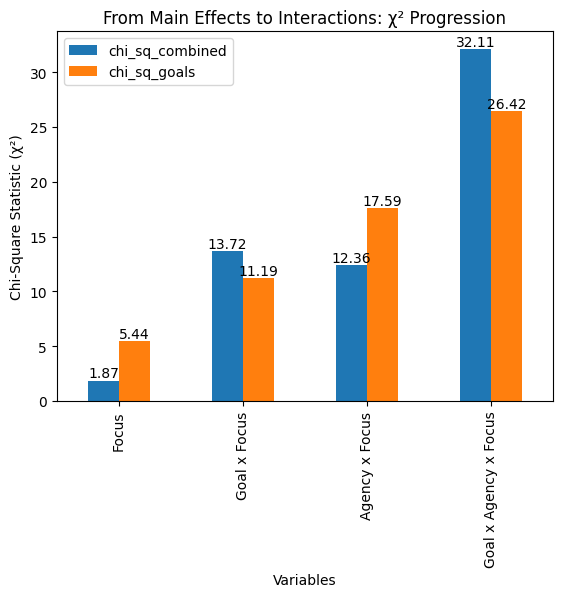

In [158]:
ax = chi_sq_df.plot(x = "effect_type", y = ["chi_sq_combined", "chi_sq_goals"], kind = "bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("From Main Effects to Interactions: χ² Progression")
plt.xlabel("Variables")
plt.ylabel("Chi-Square Statistic (χ²)")
plt.show()



## Figure 2: Declining p-values

In [159]:
p_value_df = pd.DataFrame({"effect_type": effect_type, "p_combined": p_combined, "p_goals": p_goals})
p_value_df.set_index("effect_type")

,p_combined,p_goals
effect_type,,
Focus,0.3934,0.0660
Goal x Focus,0.1863,0.0827
Agency x Focus,0.0543,0.0073
Goal x Agency x Focus,0.0755,0.0229


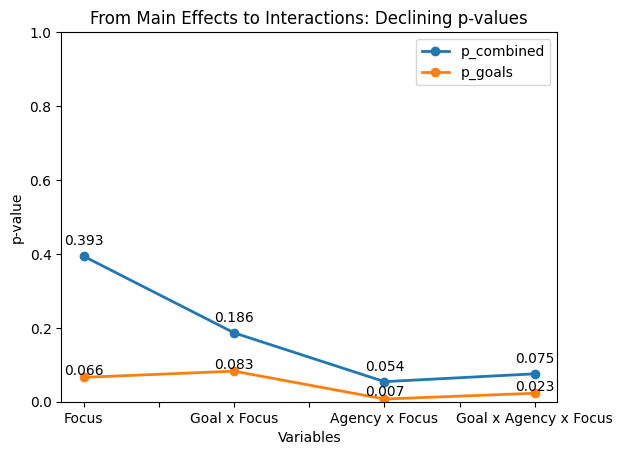

In [160]:
ax = p_value_df.plot(
    x="effect_type",
    y=["p_combined", "p_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "p_combined":
        offset = (0, 8)
    else:
        offset = (0, 2)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("From Main Effects to Interactions: Declining p-values")
plt.xlabel("Variables")
plt.ylabel("p-value")
plt.ylim(0, 1)
plt.show()

Important note: Conventional significance thresholds in psycholinguistics are typically α = .01. **None of the tested models reached this threshold**; the figure is presented to illustrate the progressive reduction in p-values as interaction structure is incorporated. They y-axis starts clearly at 0.0 in order not to mislead the reader.

## Figure 3: Increasing Effect Size

In [161]:
V_df = pd.DataFrame({"effect_type": effect_type, "V_combined": V_combined, "V_goals": V_goals})
V_df.set_index("effect_type")

,V_combined,V_goals
effect_type,,
Focus,0.098,0.204
Goal x Focus,0.188,0.207
Agency x Focus,0.178,0.259
Goal x Agency x Focus,0.287,0.318


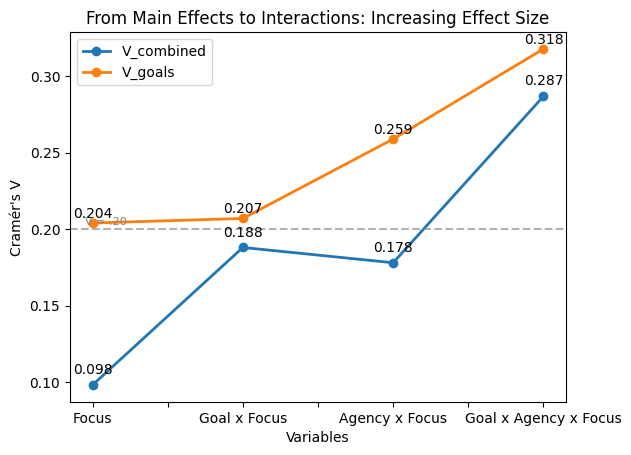

In [162]:
ax = V_df.plot(
    x="effect_type",
    y=["V_combined", "V_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "V_combined":
        offset = (0, 8)
    else:
        offset = (0, 4)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("From Main Effects to Interactions: Increasing Effect Size")

plt.axhline(
     y=0.20,
     linestyle="--",
     alpha=0.6,
     color = "grey"
     )

plt.text(
    -0.05,
    0.203,
    'V = .20',
    fontsize = 8,
    color="grey"
)

plt.xlabel("Variables")
plt.ylabel("Cramér's V")
plt.show()

For the actors subgroup, reversibility alone exhibited a negligible association with response distributions (V = .038). However, effect size increased consistently as goal structure and agency were incorporated into the model, reaching V = .255 for the full interaction model. Not only does this pattern suggest that reversibility influences actors responses primarily through its interaction with agency and goal structure rather than as an isolated factor but also that, once reversibility is contextualized by goals and agency, actors show stronger structure than the overall subgroup.

## Interpretation

Across both the overall and actors subgroups, progressively specifying the interaction structure (reversibility → goal × reversibility → agency × reversibility → goal × agency × reversibility) was associated with increasing effect sizes (Cramér’s V) and decreasing p-values. Although none of the models reached the conventional α = .01 threshold, the consistent progression suggests that reversibility effects become more structured and informative when interpreted jointly with agency and goal type rather than in isolation.

## Summary Results: Goals vs. No Goals

1. Figure 1: χ² Difference
2. Figure 2: Similar p-values
3. Figure 3: Increasing Effect Size

In [163]:
effect_type = ["Focus", "Agency x Focus"]

chi_sq_combined = [1.866, 12.364]
chi_sq_goals = [5.437, 17.590]
chi_sq_no_goals = [1.983, 5.240]

p_combined = [0.3934, 0.0543]
p_goals = [0.0660, 0.0073]
p_no_goals = [0.3710, 0.5134]

V_combined = [0.098,  0.178]
V_goals = [0.204, 0.259]
V_no_goals = [0.176, 0.202]

## Figure 1: χ² Difference

In [164]:
chi_sq_df = pd.DataFrame({"effect_type": effect_type, "chi_sq_combined": chi_sq_combined, "chi_sq_goals": chi_sq_goals, "chi_sq_no_goals": chi_sq_no_goals})
chi_sq_df.set_index("effect_type")

,chi_sq_combined,chi_sq_goals,chi_sq_no_goals
effect_type,,,
Focus,1.866,5.437,1.983
Agency x Focus,12.364,17.590,5.240


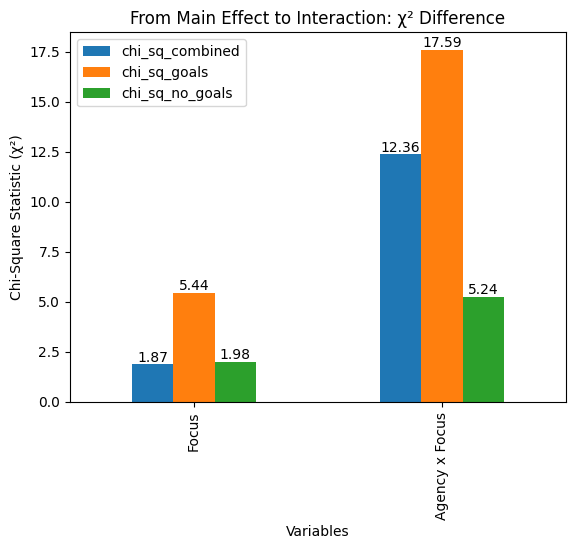

In [165]:
ax = chi_sq_df.plot(x = "effect_type", y = ["chi_sq_combined", "chi_sq_goals", "chi_sq_no_goals"], kind = "bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("From Main Effect to Interaction: χ² Difference")
plt.xlabel("Variables")
plt.ylabel("Chi-Square Statistic (χ²)")
plt.show()

## Figure 2: Increasing p-values

In [166]:
p_value_df = pd.DataFrame({"effect_type": effect_type, "p_combined": p_combined, "p_goals": p_goals, "p_no_goals": p_no_goals})
p_value_df.set_index("effect_type")

,p_combined,p_goals,p_no_goals
effect_type,,,
Focus,0.3934,0.0660,0.3710
Agency x Focus,0.0543,0.0073,0.5134


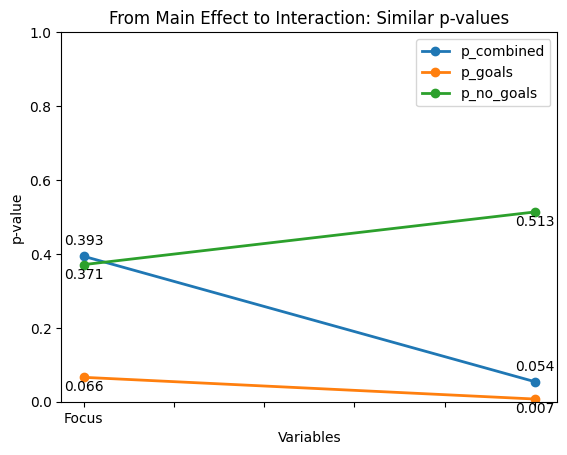

In [170]:
ax = p_value_df.plot(
    x="effect_type",
    y=["p_combined","p_goals", "p_no_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "p_combined":
        offset = (0, 8)
    else:
        offset = (0, -10)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("From Main Effect to Interaction: Similar p-values")
plt.xlabel("Variables")
plt.ylabel("p-value")
plt.ylim(0, 1)
plt.show()

## Figure 3: Increasing Effect Size

In [168]:
V_df = pd.DataFrame({"effect_type": effect_type, "V_combined": V_combined,"V_goals": V_goals, "V_no_goals": V_no_goals})
V_df.set_index("effect_type")

,V_combined,V_goals,V_no_goals
effect_type,,,
Focus,0.098,0.204,0.176
Agency x Focus,0.178,0.259,0.202


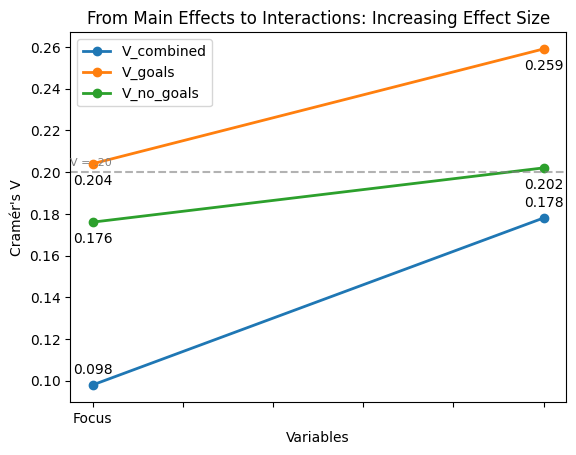

In [169]:
ax = V_df.plot(
    x="effect_type",
    y=["V_combined", "V_goals", "V_no_goals"],
    marker="o",
    linewidth=2
    )

for line in ax.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()

    if line.get_label() == "V_combined":
        offset = (0, 8)
    else:
        offset = (0, -15)

    for x, y in zip(x_data, y_data):
        ax.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=offset,
            ha="center"
            )

plt.title("From Main Effects to Interactions: Increasing Effect Size")

plt.axhline(
     y=0.20,
     linestyle="--",
     alpha=0.6,
     color = "grey"
     )

plt.text(
    -0.05,
    0.203,
    'V = .20',
    fontsize = 8,
    color="grey"
)

plt.xlabel("Variables")
plt.ylabel("Cramér's V")
plt.show()